In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
url = url = "https://raw.githubusercontent.com/avikumart/Road-Traffic-Severity-Classification-Project/main/RTA%20Dataset.csv"

df = pd.read_csv(url)

df.head()



,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
# Shape of Dataset
print("Shape of Dataset:", df.shape)

# First 5 rows
df.head()

# Dataset Information
df.info()

# Column Names
print("\nColumn Names:\n")
print(df.columns)

# Statistical Summary
df.describe(include='all')

Shape of Dataset: (12316, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  R

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing Values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

# Total Missing Values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity               

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


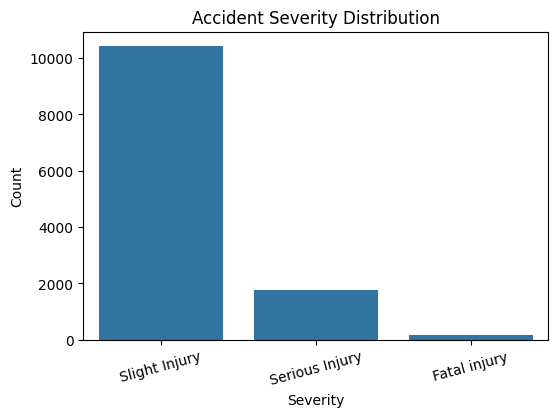

In [5]:
# Count of Accident Severity
print(df["Accident_severity"].value_counts())

# Bar Plot
plt.figure(figsize=(6,4))
sns.countplot(x="Accident_severity", data=df)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.xticks(rotation=15)

plt.show()

In [6]:
print(df.dtypes)

Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty           object
Casualty_sev

In [7]:
# Separate Categorical and Numerical Columns

cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

# Fill Categorical Missing Values with "Unknown"
for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)

# Fill Numerical Missing Values with Median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing Values Filled Successfully!")

Missing Values Filled Successfully!


In [8]:
print("Total Missing Values After Cleaning:")
print(df.isnull().sum().sum())

Total Missing Values After Cleaning:
0


In [9]:
# Convert Time into Hour

df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

# Drop Original Time Column
df.drop("Time", axis=1, inplace=True)

df.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1


In [10]:
target = "Accident_severity"

X = df.drop(columns=[target])
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (12316, 31)
Target Shape: (12316,)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Copy Features
X_encoded = X.copy()

# Label Encode Feature Columns
feature_encoders = {}

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        feature_encoders[col] = le

# Encode Target Column
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [12]:
# Target Mapping

mapping = dict(zip(target_encoder.classes_,
                   target_encoder.transform(target_encoder.classes_)))

print(mapping)

{'Fatal injury': np.int64(0), 'Serious Injury': np.int64(1), 'Slight Injury': np.int64(2)}


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (9852, 31)
Testing Data : (2464, 31)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.4943181818181818


In [16]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7686688311688312


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8465909090909091


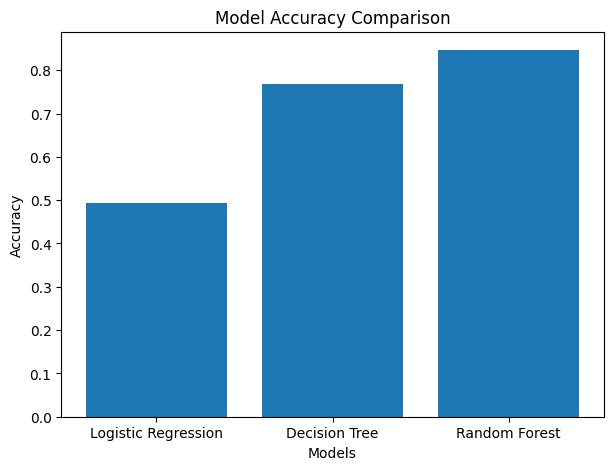

Logistic Regression : 0.4943181818181818
Decision Tree : 0.7686688311688312
Random Forest : 0.8465909090909091


In [18]:
# Accuracy Comparison

lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

print("Logistic Regression :", lr_acc)
print("Decision Tree :", dt_acc)
print("Random Forest :", rf_acc)

In [19]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report\n")

print(classification_report(
    y_test,
    rf_pred,
    target_names=target_encoder.classes_
))

Random Forest Classification Report

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       1.00      0.01      0.01       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.62      0.34      0.31      2464
  weighted avg       0.86      0.85      0.78      2464



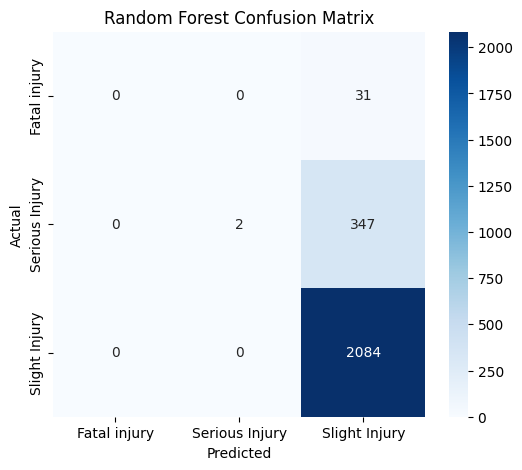

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

                        Feature  Importance
30                         Hour    0.086814
20         Number_of_casualties    0.080052
29            Cause_of_accident    0.060358
0                   Day_of_week    0.056843
6               Type_of_vehicle    0.052228
19  Number_of_vehicles_involved    0.048208
10        Area_accident_occured    0.045070
5            Driving_experience    0.044850
1            Age_band_of_driver    0.042199
13            Types_of_Junction    0.041470


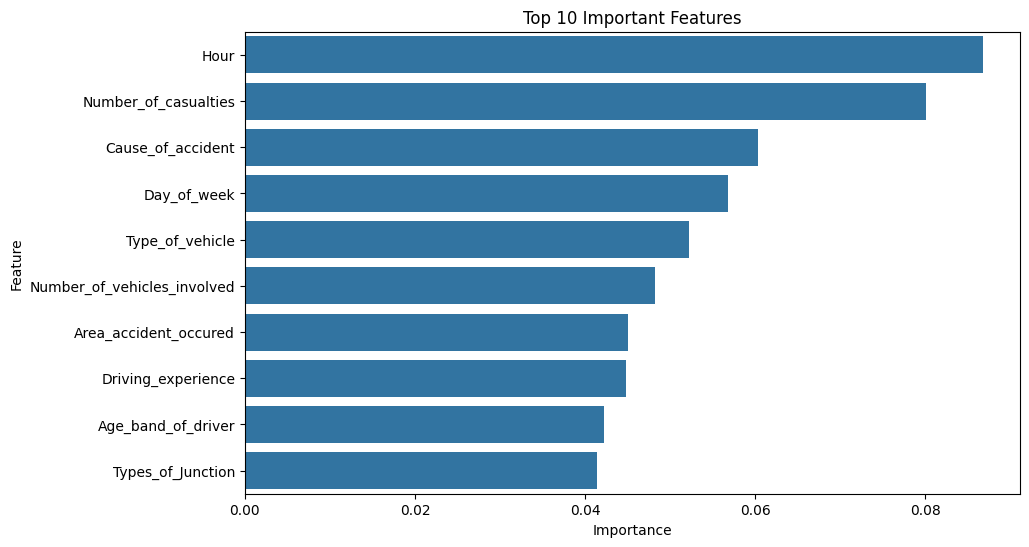

In [21]:
importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [22]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

actual = y_test[0]

print("Predicted Severity :",
      target_encoder.inverse_transform(prediction)[0])

print("Actual Severity :",
      target_encoder.inverse_transform([actual])[0])

Predicted Severity : Slight Injury
Actual Severity : Slight Injury


In [23]:
best_model = max({
    "Logistic Regression": lr_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}, key=lambda x: {
    "Logistic Regression": lr_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}[x])

print("Best Model is :", best_model)

Best Model is : Random Forest


In [24]:
def predict_accident(sample_data):
    prediction = rf.predict(sample_data)
    result = target_encoder.inverse_transform(prediction)
    return result[0]

# Example
sample = X_test.iloc[[5]]

print("Predicted Severity :", predict_accident(sample))
print("Actual Severity :", target_encoder.inverse_transform([y_test[5]])[0])

Predicted Severity : Slight Injury
Actual Severity : Slight Injury


In [25]:
import joblib

joblib.dump(rf, "road_accident_model.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [26]:
loaded_model = joblib.load("road_accident_model.pkl")

prediction = loaded_model.predict(X_test.iloc[[10]])

print("Prediction :",
      target_encoder.inverse_transform(prediction)[0])

Prediction : Slight Injury


In [27]:
print("="*60)
print("ROAD ACCIDENT SEVERITY PREDICTION PROJECT")
print("="*60)

print(f"Dataset Shape : {df.shape}")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")

print("\nModel Accuracy")
print("------------------------")
print(f"Logistic Regression : {lr_acc:.4f}")
print(f"Decision Tree       : {dt_acc:.4f}")
print(f"Random Forest       : {rf_acc:.4f}")

print("\nBest Model :", best_model)

print("\nProject Completed Successfully!")

ROAD ACCIDENT SEVERITY PREDICTION PROJECT
Dataset Shape : (12316, 32)
Training Samples : 9852
Testing Samples : 2464

Model Accuracy
------------------------
Logistic Regression : 0.4943
Decision Tree       : 0.7687
Random Forest       : 0.8466

Best Model : Random Forest

Project Completed Successfully!
